# Notebook 1: Dataset Exploration — Understanding SAMSum

**No machine learning happens here.** This notebook answers:
1. What does SAMSum look like?
2. How big is it (train / val / test)?
3. How long are the dialogues vs the summaries?
4. How much compression does a good summary achieve?
5. Why is this task non-trivial?

**Connects to:** `training/dataset.py` → `load_samsum()`
```python
# From training/dataset.py
def load_samsum():
    return load_dataset('samsum')
```

In [ ]:
# Cell 1 — Install dependencies
#!pip install -q "datasets>=4.6.0" pandas matplotlib

In [2]:
!hf auth login

A new version of huggingface_hub (1.5.0) is available! You are using version 1.4.1.
To update, run: pip install -U huggingface_hub

User is already logged in.


In [ ]:
from huggingface_hub import login
login(token="xxxxxxxxx")

In [3]:
# Cell 2 — Load SAMSum and inspect split sizes + one raw example
from datasets import load_dataset

dataset = load_dataset("knkarthick/samsum")

print('=== Split sizes ===')
for split, ds in dataset.items():
    print(f'  {split:12s}: {len(ds):,} examples')

print('\n=== First training example ===')
ex = dataset['train'][0]
print('DIALOGUE:')
print(ex['dialogue'])
print('\nSUMMARY:')
print(ex['summary'])

/Users/sourangshupal/Downloads/text-summar-project/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


=== Split sizes ===
  train       : 14,731 examples
  validation  : 818 examples
  test        : 819 examples

=== First training example ===
DIALOGUE:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

SUMMARY:
Amanda baked cookies and will bring Jerry some tomorrow.


## What is SAMSum?

SAMSum is a corpus of ~16,000 messenger-style conversations, each paired with a human-written **abstractive** summary.

- **Speaker-labelled turns** — every line starts with a name and a colon
- **Informal language** — abbreviations, emoji, typos, code-switching
- **Abstractive summaries** — the summary rewrites the gist, not just extracts sentences
- **Implied context** — who did what, when, and why must be inferred from the conversation flow

This is harder than summarizing a news article because the "important" information is scattered across many short turns.

In [3]:
# Cell 3 — Compute statistics over the training split
train = dataset['train']

dialogue_lens = [len(ex['dialogue']) for ex in train]
summary_lens  = [len(ex['summary'])  for ex in train]
ratios        = [d / s for d, s in zip(dialogue_lens, summary_lens)]

print('=== Training split statistics ===')
print(f'  Dialogue — avg: {sum(dialogue_lens)/len(dialogue_lens):,.0f} chars')
print(f'             min: {min(dialogue_lens):,}  max: {max(dialogue_lens):,}')
print(f'  Summary  — avg: {sum(summary_lens)/len(summary_lens):,.0f} chars')
print(f'             min: {min(summary_lens):,}  max: {max(summary_lens):,}')
print(f'  Compression ratio (dialogue/summary) — avg: {sum(ratios)/len(ratios):.1f}x')

=== Training split statistics ===
  Dialogue — avg: 502 chars
             min: 29  max: 5,474
  Summary  — avg: 110 chars
             min: 3  max: 300
  Compression ratio (dialogue/summary) — avg: 4.7x


In [4]:
# Cell 4 — Show 5 varied examples across the length spectrum
import random
random.seed(42)

train_list = list(train)
candidates = random.sample(train_list, 200)
candidates.sort(key=lambda x: len(x['dialogue']))

# Pick 5 spread evenly across lengths
indices = [0, 49, 99, 149, 199]
examples = [candidates[i] for i in indices]

print('=== 5 Examples Across the Length Spectrum ===\n')
for i, ex in enumerate(examples, 1):
    print(f'Example {i} ({len(ex["dialogue"])} chars):')
    print(ex['dialogue'])
    print(f'\n→ Summary:')
    print(ex['summary'])
    print('─' * 72)

=== 5 Examples Across the Length Spectrum ===

Example 1 (65 chars):
Mary: u need help?
Tom: No, it's ok. Don't worry.
Mary: Luv u! :*

→ Summary:
Tom is fine and doesn't need Mary's help.
────────────────────────────────────────────────────────────────────────
Example 2 (195 chars):
Peter: <file_photo>
Peter: Einar Selvik in Poland 
Reginald: AT LAST
Reginald: my prayers have been heard
Samuel: how much for the tickets?
Peter: 40$
Samuel: sounds cool, i'm in
Reginald: me too

→ Summary:
Peter announces that Einar Selvik is coming to Poland. Reginald and Samuel want to buy tickets for the concert.
────────────────────────────────────────────────────────────────────────
Example 3 (382 chars):
Olivia: When is your birthday?
Harry: It's on Saturday. You remembered :-)
Olivia: I remembered it was in November didn't remember when exactly
Harry: I'm planning to have a little party at home
Harry: But I guess you will be going to Belgium
Olivia: I'm planing to. But it depends on my supervisor


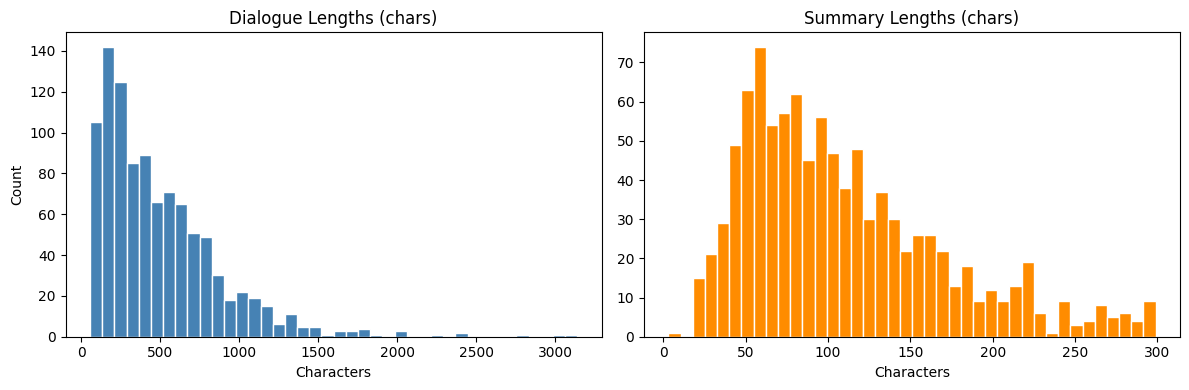

In [5]:
# Cell 5 — Plot dialogue and summary length distributions
import matplotlib.pyplot as plt
import random
random.seed(42)

sample = random.sample(list(train), 1000)
d_lens = [len(ex['dialogue']) for ex in sample]
s_lens = [len(ex['summary'])  for ex in sample]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(d_lens, bins=40, color='steelblue', edgecolor='white')
ax1.set_title('Dialogue Lengths (chars)')
ax1.set_xlabel('Characters')
ax1.set_ylabel('Count')

ax2.hist(s_lens, bins=40, color='darkorange', edgecolor='white')
ax2.set_title('Summary Lengths (chars)')
ax2.set_xlabel('Characters')

plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — Word-count compression table (10 examples)
import random
random.seed(42)

sample10 = random.sample(list(train), 10)

print(f'{"#":<4} {"Dialogue words":>15} {"Summary words":>14} {"Ratio":>7}')
print('─' * 45)

total_d, total_s = 0, 0
for i, ex in enumerate(sample10, 1):
    d_words = len(ex['dialogue'].split())
    s_words = len(ex['summary'].split())
    ratio   = d_words / max(s_words, 1)
    total_d += d_words
    total_s += s_words
    print(f'{i:<4} {d_words:>15} {s_words:>14} {ratio:>7.1f}x')

print('─' * 45)
avg_ratio = total_d / max(total_s, 1)
print(f'{"AVG":<4} {total_d//10:>15} {total_s//10:>14} {avg_ratio:>7.1f}x')

#     Dialogue words  Summary words   Ratio
─────────────────────────────────────────────
1                176             21     8.4x
2                 50             13     3.8x
3                 18             10     1.8x
4                114             23     5.0x
5                 53             20     2.6x
6                 65             21     3.1x
7                262             31     8.5x
8                 23              6     3.8x
9                 52             18     2.9x
10                67              8     8.4x
─────────────────────────────────────────────
AVG               88             17     5.1x


## Key Takeaways

- **Typical dialogue** is 5–20 conversational turns, 200–800 characters
- **Summaries compress ~5–8×** — a 500-char dialogue becomes a ~80-char summary
- **Why this is hard:**
  - Multi-speaker: the model must track who said what and to whom
  - Signal vs. noise: greetings, filler turns and off-topic tangents must be filtered out
  - Implicit context: important info is often implied, not stated directly
  - Noisy-to-fluent: the output must be grammatically clean even though the input is informal

---

**Next:** In `02_tokenization_explained.ipynb` we will see how this text gets converted into numbers (token IDs) that the model can actually process.